In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
%matplotlib inline

In [ ]:
import yfinance as yf
import datetime as dt


In [ ]:
stock='AMZN'
start=dt.datetime(2015,1,1)
end=dt.datetime.now()
df=yf.download(stock,start,end)

/tmp/ipython-input-1783030295.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2015-01-02,15.4260,15.7375,15.3480,15.6290,55664000
2015-01-05,15.1095,15.4190,15.0425,15.3505,55484000
2015-01-06,14.7645,15.1500,14.6190,15.1120,70380000
2015-01-07,14.9210,15.0640,14.7665,14.8750,52806000
2015-01-08,15.0230,15.1570,14.8055,15.0160,61768000


In [ ]:
df.shape

(2765, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AMZN)   2765 non-null   float64
 1   (High, AMZN)    2765 non-null   float64
 2   (Low, AMZN)     2765 non-null   float64
 3   (Open, AMZN)    2765 non-null   float64
 4   (Volume, AMZN)  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
count,2765.000000,2765.000000,2765.000000,2765.000000,2.765000e+03
mean,111.714225,113.006832,110.364785,111.751590,7.329700e+07
std,61.701738,62.414756,60.993023,61.755596,4.023596e+07
min,14.347500,14.539500,14.262500,14.314000,1.142050e+07
25%,50.146999,50.490002,49.860001,50.297501,4.790030e+07
50%,99.740997,100.919998,98.122002,99.825500,6.260400e+07
75%,163.293503,165.199997,161.434494,163.500000,8.721800e+07
max,254.000000,258.600006,252.899994,255.360001,4.771220e+08


In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AMZN,0
High,AMZN,0
Low,AMZN,0
Open,AMZN,0
Volume,AMZN,0


In [ ]:
df=df.reset_index()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AMZN)   2765 non-null   float64
 1   (High, AMZN)    2765 non-null   float64
 2   (Low, AMZN)     2765 non-null   float64
 3   (Open, AMZN)    2765 non-null   float64
 4   (Volume, AMZN)  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB


In [ ]:
import plotly.graph_objects as go

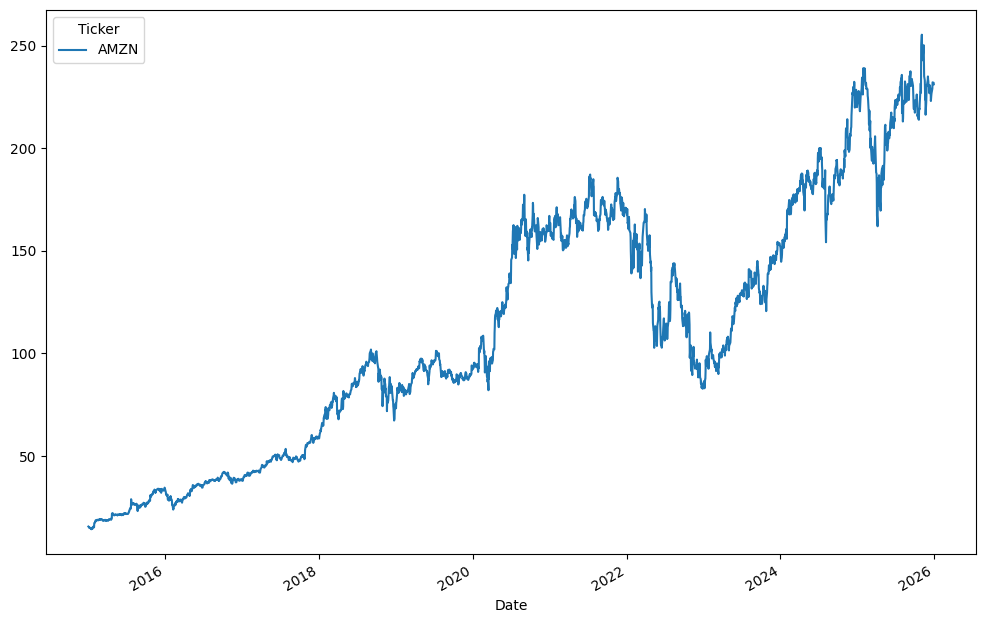

In [ ]:
df.plot( y='Open', kind='line',figsize=(12,8))
plt.show()

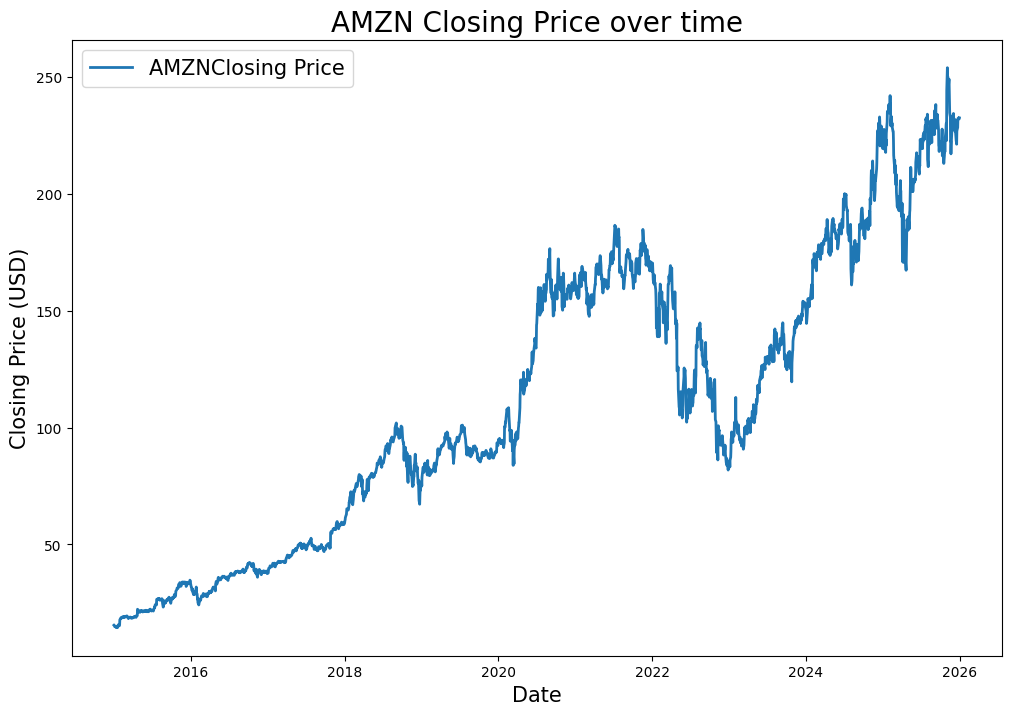

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(df['Close'],label=f'{stock}Closing Price',linewidth=2)
plt.title(f'{stock} Closing Price over time',fontsize=20)
plt.xlabel('Date',fontsize=15)
plt.ylabel('Closing Price (USD)',fontsize=15)
plt.legend(fontsize=15)
plt.show()


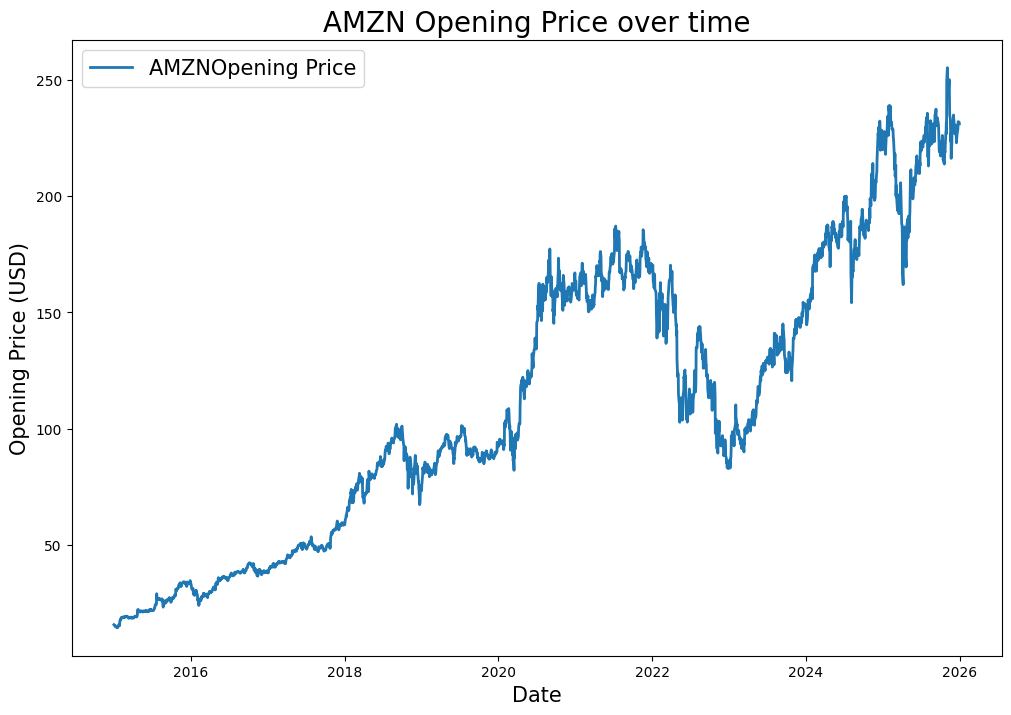

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(df['Open'],label=f'{stock}Opening Price',linewidth=2)
plt.title(f'{stock} Opening Price over time',fontsize=20)
plt.xlabel('Date',fontsize=15)
plt.ylabel('Opening Price (USD)',fontsize=15)
plt.legend(fontsize=15)
plt.show()

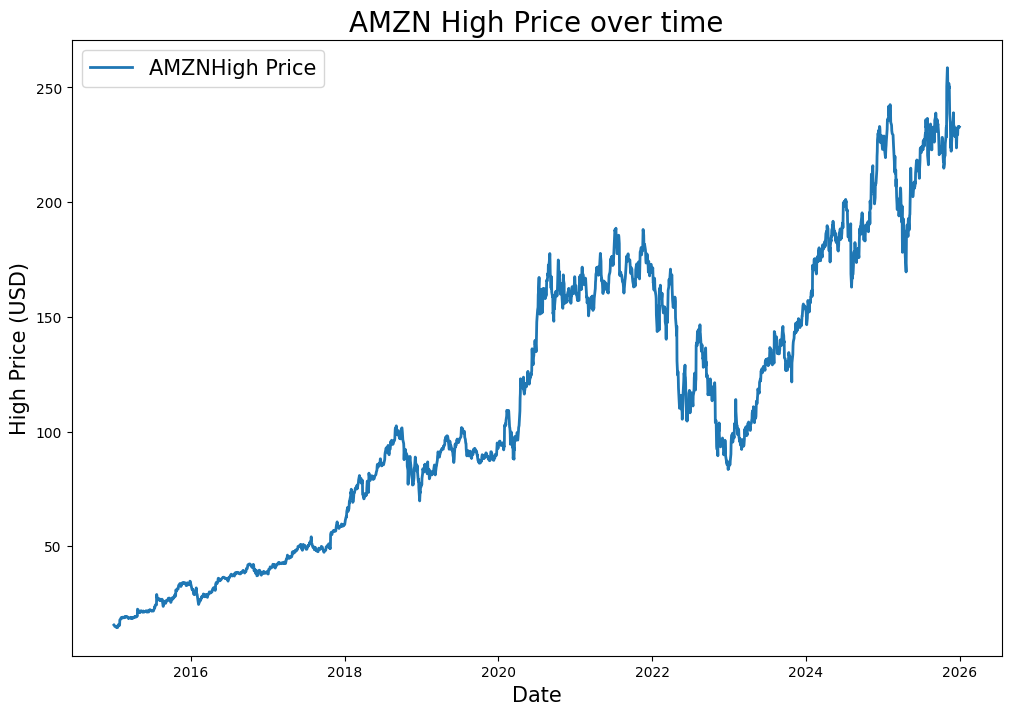

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(df['High'],label=f'{stock}High Price',linewidth=2)
plt.title(f'{stock} High Price over time',fontsize=20)
plt.xlabel('Date',fontsize=15)
plt.ylabel('High Price (USD)',fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [ ]:
#Moving average
ma100=df.Close.rolling(100).mean()
ma200=df.Close.rolling(200).mean()


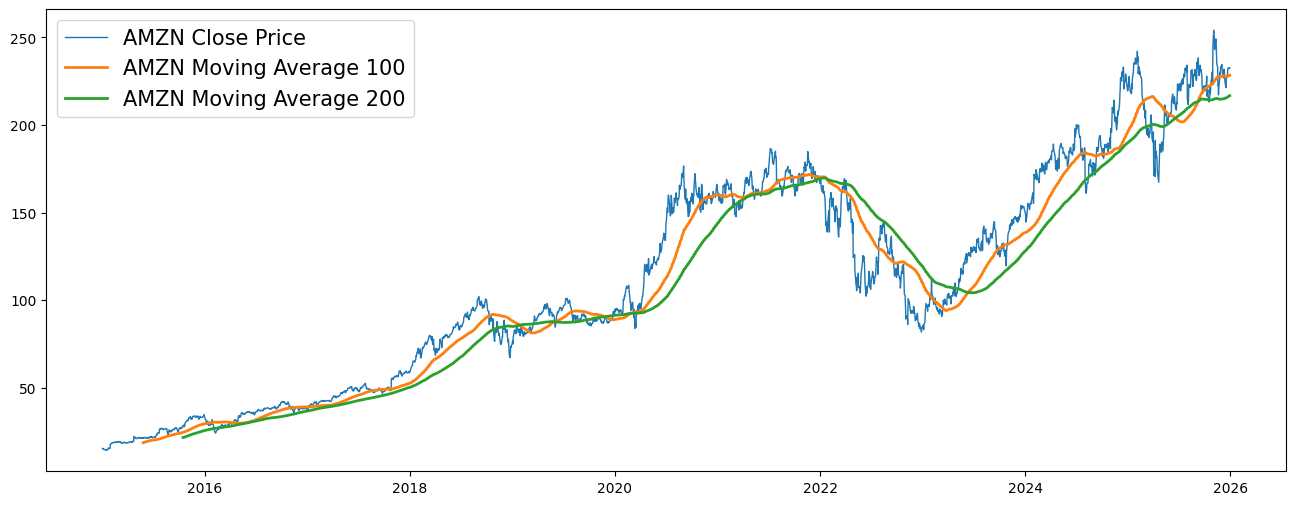

In [ ]:
from matplotlib import colors
plt.figure(figsize=(16,6))
plt.plot(df['Close'],label=f'{stock} Close Price',linewidth=1)
plt.plot(ma100,label=f'{stock} Moving Average 100',linewidth=2)
plt.plot(ma200,label=f'{stock} Moving Average 200',linewidth=2)
plt.legend(fontsize=15)
plt.show()

In [ ]:
df['Daily Return']=df['Close'].pct_change()

<Axes: xlabel='Date'>

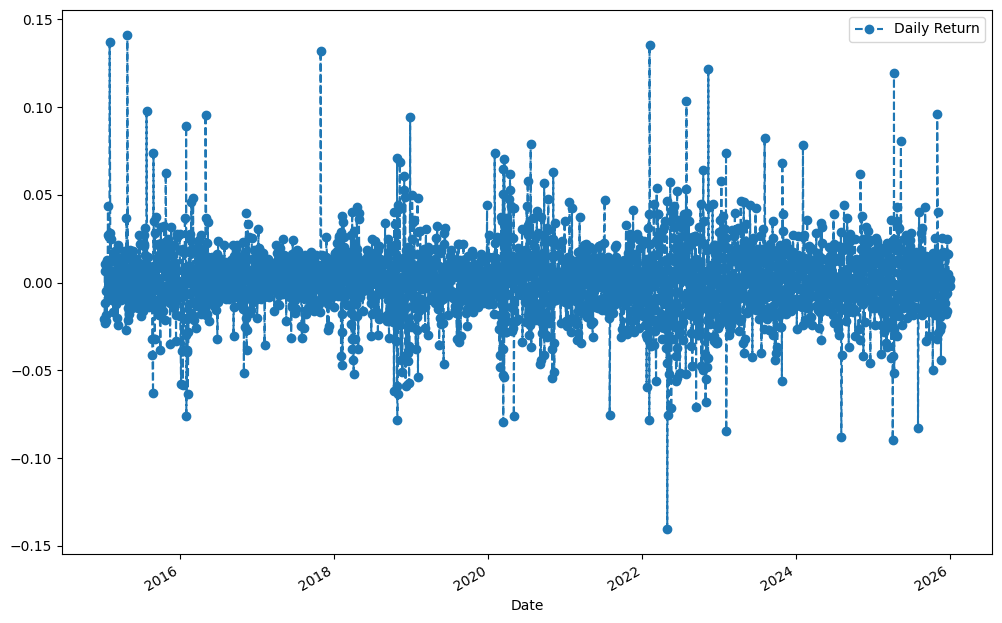

In [ ]:
df['Daily Return'].plot(legend=True, linestyle='--', marker='o',figsize=(12,8))


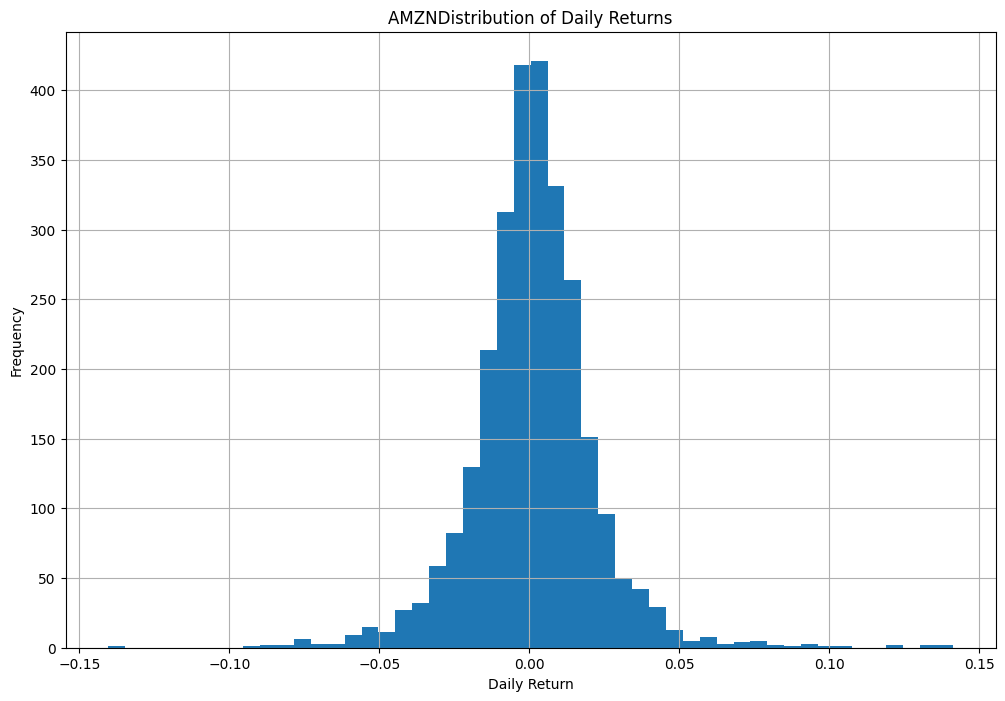

In [ ]:
df['Daily Return'].hist(bins=50,figsize=(12,8))
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title(f'{stock}Distribution of Daily Returns')
plt.show()

In [ ]:
df_train=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
df_test=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])


In [ ]:
df_train.shape

(1935, 1)

In [ ]:
df_test.shape

(830, 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [ ]:
df_tain_array=scaler.fit_transform(df_train)

In [ ]:
df_tain_array

array([[0.00626223],
       [0.0044245 ],
       [0.00242128],
       ...,
       [0.64894064],
       [0.66850826],
       [0.67048252]])

In [ ]:
x_train=[]
y_train=[]

In [ ]:
for i in range(100,df_tain_array.shape[0]):
  x_train.append(df_tain_array[i-100:i])
  y_train.append(df_tain_array[i,0])


x_train,y_train=np.array(x_train),np.array(y_train)

In [ ]:
x_train.shape

(1835, 100, 1)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [ ]:
model=Sequential()

model.add(LSTM(64,activation='relu',return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.3))

model.add(LSTM(units=64,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=32,activation='relu',return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 100, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,187 (246.82 KB)

 Trainable params: 63,187 (246.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')


In [ ]:
model.fit(x_train,y_train,epochs=30)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.1224
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0091
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0065
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.0051
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0057
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 0.0048
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0044
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 0.0040
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 0.0038
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.0038
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0032
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0029
Epoch 13/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - loss: 0.0033
Epoch 14/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 0.0031
Epoch 15/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/s

In [ ]:
past_100=df_train.tail(100)

In [ ]:
final_df = pd.concat([past_100, df_test], ignore_index=True)


In [ ]:
final_df.shape

(930, 1)

In [ ]:
final_df.head()

Ticker,AMZN
0,152.785004
1,158.115494
2,153.998001
3,148.296005
4,144.350006


In [ ]:
input_data=scaler.fit_transform(final_df)

In [ ]:
input_data.shape

(930, 1)

In [ ]:
x_test=[]
y_test=[]

for i in range(100,input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i,0])


x_test,y_test=np.array(x_test),np.array(y_test)

In [ ]:
x_test.shape

(830, 100, 1)

In [ ]:
y_predicted=model.predict(x_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step


In [ ]:
y_predicted.shape

(830, 1)

In [ ]:
y_test.shape

(830,)

In [ ]:
scaler.scale_

array([0.00580788])

In [ ]:
scaler_factor=1/0.00580788
y_predicted=y_predicted*scaler_factor
y_test=y_test*scaler_factor

In [ ]:
rmse = np.sqrt(np.mean(((y_predicted - y_test) ** 2)))
rmse

np.float64(64.56703102132818)

In [ ]:
print(y_test.min(), y_test.max())
print(y_predicted.min(), y_predicted.max())


0.0 172.1798659751923
7.410538 156.00348


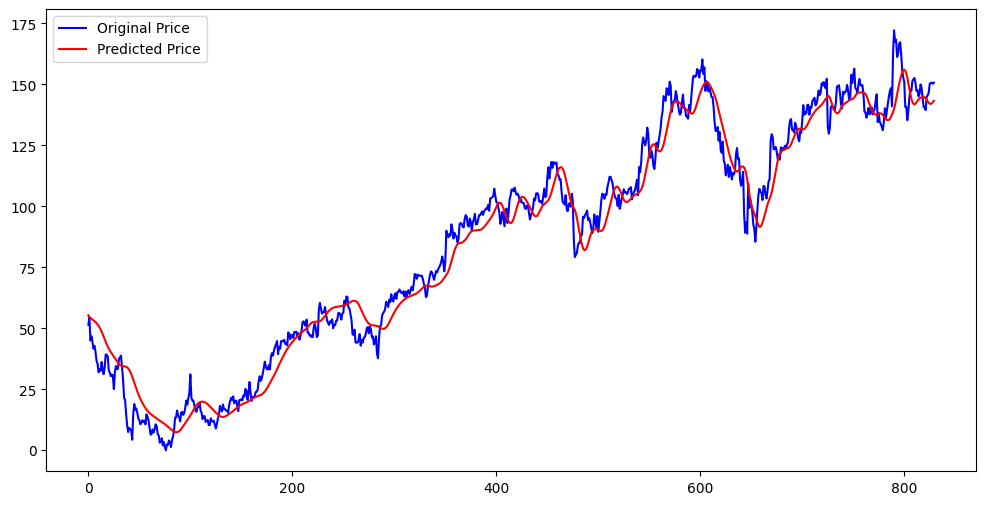

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.legend()
plt.show()

In [ ]:
model.save("stock_lstm_model.keras")


In [ ]:
import joblib

joblib.dump(scaler, "scaler.save")


['scaler.save']